In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
import numpy as np

In [54]:
df = pd.read_csv("datasets/house_prices.csv")

print(df)

     Size in Feet²          Price
0      2708.953862  610561.870414
1      1227.069622  277626.057950
2      1355.202823  276223.743585
3      1975.168248  346674.506991
4      2711.348468  478690.398500
..             ...            ...
745    1105.278121  246964.189509
746    2658.514669  605491.719523
747    2611.712692  604511.406882
748    1204.052509  268592.867383
749    2129.267544  340675.446298

[750 rows x 2 columns]


In [55]:
#Global informations about the dataset (Columns, shape, types, missing values...) 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Size in Feet²  750 non-null    float64
 1   Price          750 non-null    float64
dtypes: float64(2)
memory usage: 11.8 KB


In [56]:
#Check for Duplicate Values
if (len(df[df.duplicated()])>0):
    print("Duplicate values found in the data.")
    df.drop_duplicates(inplace=True)
else:
    print("No duplicate values detected in the data.")

No duplicate values detected in the data.


In [57]:
#Check for outliers
def outliers_detector(df: pd.DataFrame, column: str):
    if column not in df.columns:
        return

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # Determine outlier boundaries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"Detected outliers for {column}: {outliers.values if len(outliers) != 0 else "No one"}")

for column in df.columns:
    outliers_detector(df, column)

Detected outliers for Size in Feet²: No one
Detected outliers for Price: No one


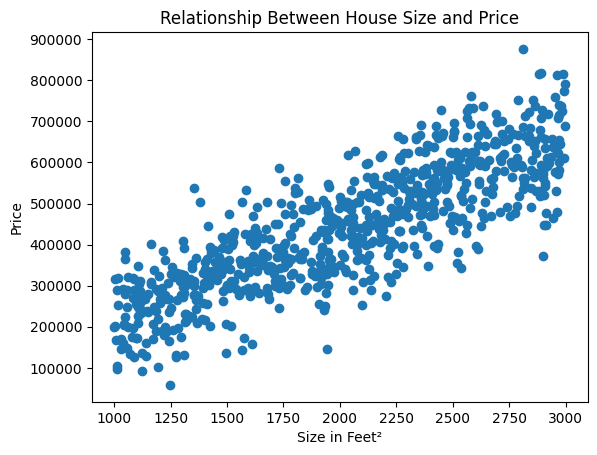

In [58]:
x, y = df['Size in Feet²'], df['Price']

plt.scatter(x, y)
plt.xlabel("Size in Feet²")
plt.ylabel("Price")
plt.title("Relationship Between House Size and Price")
plt.show()

In [59]:
# y_hat (prediction)
def f(x: pd.Series, w: float, b: float) -> pd.Series:
    return w * x + b

print("x: ", x[:2].values)
print("y_hat: ", f(x[:2], 3.2, 2000).values)


x:  [2708.95386166 1227.06962156]
y_hat:  [10668.6523573   5926.62278899]


In [60]:
# Squared Error Cost Function
def squared_error_cost(y: pd.Series, y_hat: pd.Series) -> float:
    return ((y - y_hat).pow(2)).mean() / 2

print("Squared Error Cost: ", squared_error_cost(y[:2], f(x[:2], 3.2, 2000)))

Squared Error Cost:  108423114034.15833


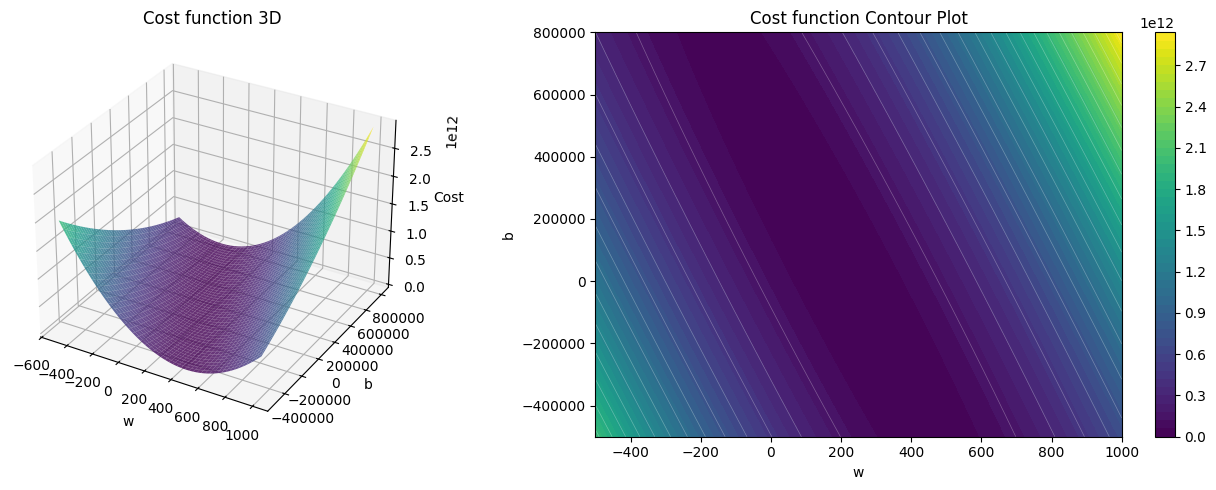

In [61]:
w_range = np.linspace(-500, 1000, 100)
b_range = np.linspace(-500000, 800000, 100)

W, B = np.meshgrid(w_range, b_range)

Z = np.array([
    [squared_error_cost(y, f(x, w, b)) for w in w_range]
    for b in b_range
])

fig = plt.figure(figsize=(14, 5))

ax3d = fig.add_subplot(121, projection='3d')
ax3d.plot_surface(W, B, Z, cmap='viridis', alpha=0.8)
ax3d.set_xlabel('w')
ax3d.set_ylabel('b')
ax3d.set_zlabel('Cost')
ax3d.set_title('Cost function 3D')

ax3d = fig.add_subplot(122)
contour = ax3d.contourf(W, B, Z, levels=50, cmap='viridis')
ax3d.contour(W, B, Z, levels=20, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(contour, ax=ax3d)
ax3d.set_xlabel('w')
ax3d.set_ylabel('b')
ax3d.set_title('Cost function Contour Plot')

plt.tight_layout()
plt.show()

# Interpretation of Squared Error Cost
The Interpreting Squared Error Cost involves understanding the magnitude of the error and its implications for the model's performance.

* A lower Squared Error Cost indicates that the model's predictions are closer to the actual values, signifying better accuracy.
* Conversely, a higher Squared Error Cost suggests that the model's predictions deviate further from the true value, indicating poorer performance.

In [62]:
def dw(w: float, b: float, x: pd.Series, y: pd.Series) -> float:
    return ((f(x, w, b) - y) * x).mean()

def db(w: float, b: float, x: pd.Series, y: pd.Series) -> float:
    return (f(x, w, b) - y).mean()

def gradient_descent(
    x: pd.Series,
    y: pd.Series,
    alpha: float = 0.001,
    max_iter: int = 20,
    epsilon: float = 0.2
):
    w, b, nbr_iter = 0, 0, 0
    costs = []

    while (nbr_iter < max_iter):
        tmp_w = w - alpha * dw(w, b, x, y)
        tmp_b = b - alpha * db(w, b, x, y)
        w, b = tmp_w, tmp_b
        nbr_iter += 1
        cost = squared_error_cost(y, f(x, w, b))
        costs.append(cost)
        if cost < epsilon:
            break

    return (w, b, costs)

In [63]:
w, b, costs = gradient_descent(x, y, alpha=0.001)

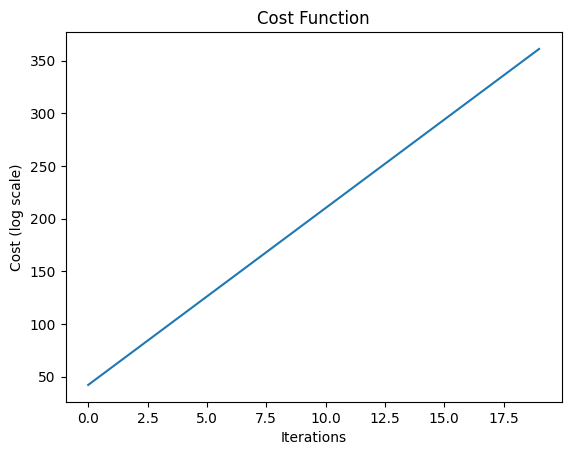

In [64]:
plt.plot(range(len(costs)), np.log(costs))
plt.xlabel('Iterations')
plt.ylabel('Cost (log scale)')
plt.title('Cost Function')
plt.show()

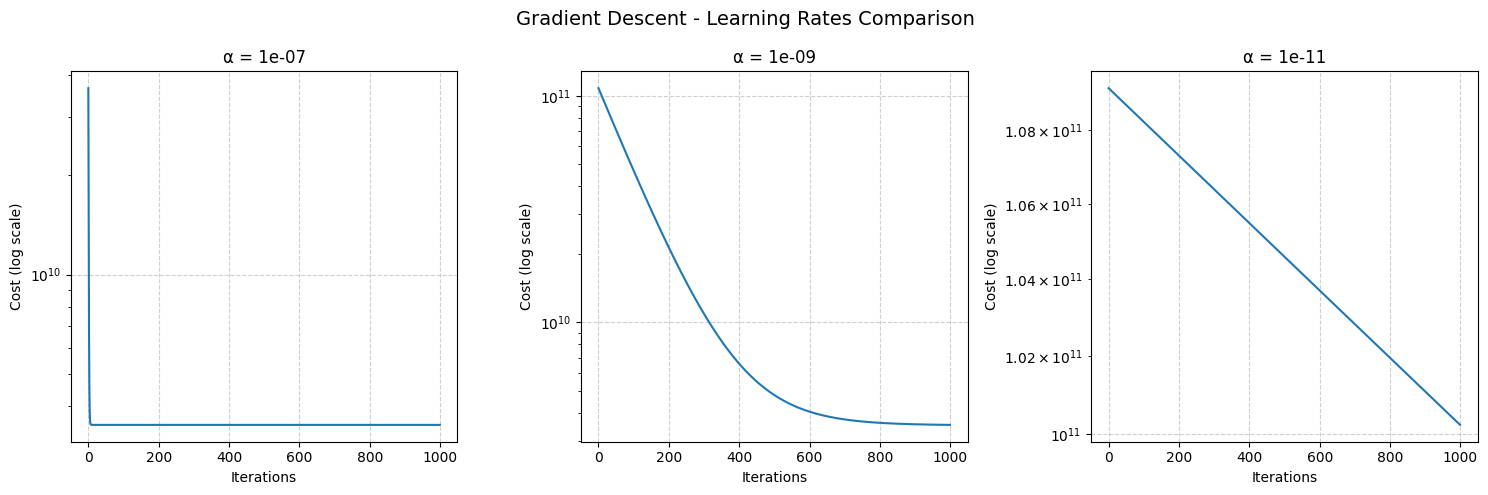

In [65]:
learning_rates = [1/(10**7), 1/(10**9), 1/(10**11)]
costs = []

for alpha in learning_rates:
    costs.append(gradient_descent(x, y, alpha=alpha, max_iter=1000)[2])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (alpha, cost) in enumerate(zip(learning_rates, costs)):
    axes[i].plot(cost)
    axes[i].set_yscale('log')
    axes[i].set_xlabel('Iterations')
    axes[i].set_ylabel('Cost (log scale)')
    axes[i].set_title(f'α = {alpha:.0e}')
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Gradient Descent - Learning Rates Comparison', fontsize=14)

plt.tight_layout()
plt.show()

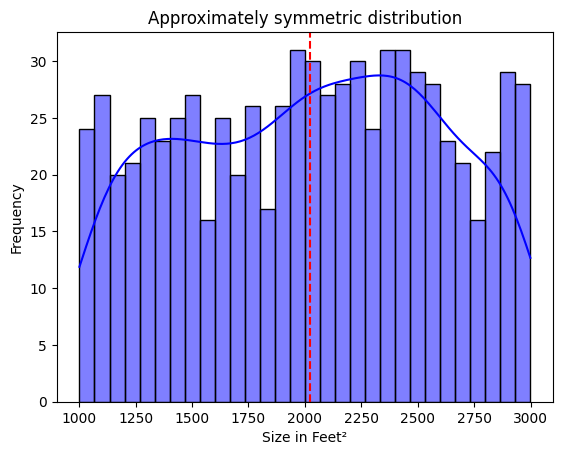

In [66]:
from scipy.stats import skew

sk = skew(x)
if abs(sk) < 0.1:
    interpretation = "Approximately symmetric distribution"
elif sk > 0:
    interpretation = "Right-skewed distribution (positive skew)"
else:
    interpretation = "Left-skewed distribution (negative skew)"

sns.histplot(x, bins=30, kde=True, color="blue")
plt.axvline(x=x.mean(), color='red', linestyle='--')
plt.title(interpretation)
plt.xlabel("Size in Feet²")
plt.ylabel("Frequency")
plt.show()

In [67]:
x_normalized = (x - x.mean()) / x.std()
x_normalized.describe()

count    7.500000e+02
mean     2.842171e-17
std      1.000000e+00
min     -1.798082e+00
25%     -8.787757e-01
50%      5.620661e-02
75%      8.207083e-01
max      1.722936e+00
Name: Size in Feet², dtype: float64

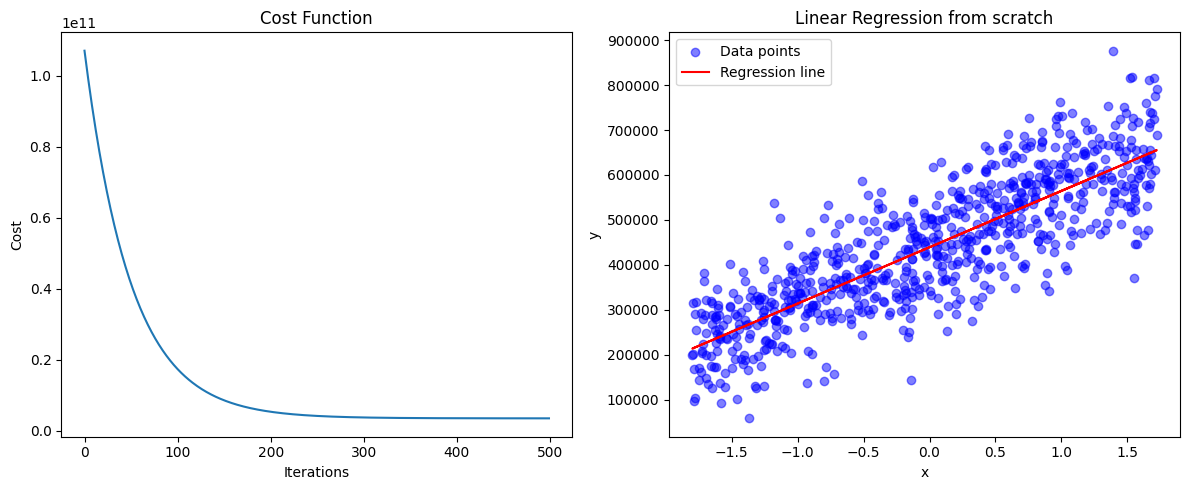

In [68]:
w, b, costs = gradient_descent(x_normalized, y, alpha=0.01, max_iter=500)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Cost Function
ax1.plot(range(len(costs)), costs)
ax1.set_xlabel('Iterations')
ax1.set_ylabel('Cost')
ax1.set_title('Cost Function')

# Scatter plot with the model wx + b
ax2.scatter(x_normalized, y, color='blue', label='Data points', alpha=0.5)
ax2.plot(x_normalized, f(x_normalized, w, b), color='red', label='Regression line')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Linear Regression from scratch')
ax2.legend()

plt.tight_layout()
plt.show()


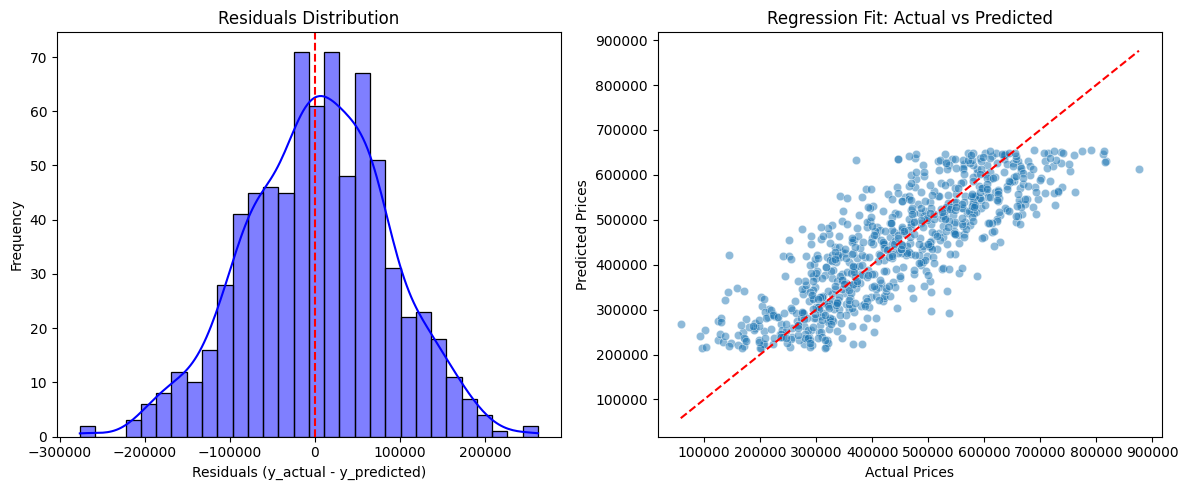

In [69]:
y_predicted = f(x_normalized, w, b)
residuals = y - y_predicted

plt.figure(figsize=(12,5))


# Plot 1: Residuals Distribution.
plt.subplot(1,2,1)
sns.histplot(residuals, bins=30, kde=True, color="blue")
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Residuals Distribution")
plt.xlabel("Residuals (y_actual - y_predicted)")
plt.ylabel("Frequency")


# Plot 2: Regression Fit (Actual vs Predicted).
plt.subplot(1,2,2)
sns.scatterplot(x=y, y=y_predicted, alpha=0.5)
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--')
plt.title("Regression Fit: Actual vs Predicted")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")


# Show plots.
plt.tight_layout()
plt.show()

In [70]:
def r2_score(y, y_hat):
    return 1 - ((y - y_hat)**2).sum() / ((y - y.mean())**2).sum()

In [71]:
print("mean squared error : ", squared_error_cost(y, y_predicted) * 2)
print("R2 : ", r2_score(y, y_predicted))

mean squared error :  7031805750.213554
R2 :  0.6934904338257197


In [72]:
x_normalized = pd.DataFrame(x_normalized)

model = LinearRegression()
model.fit(x_normalized, y)

y_predicted = model.predict(x_normalized)

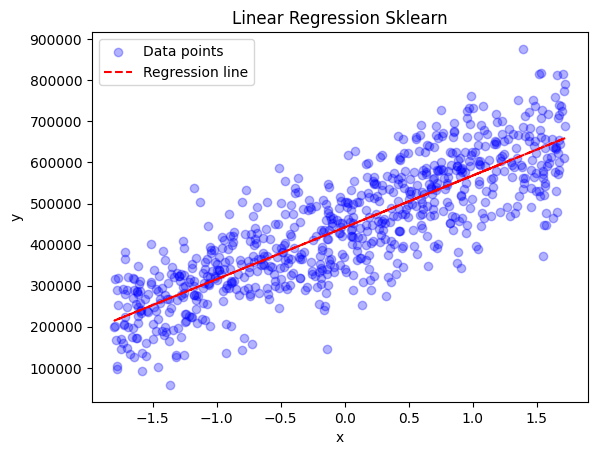

In [84]:
plt.scatter(x_normalized, y, color='blue', alpha=0.3, label='Data points')
plt.plot(x_normalized, y_predicted, color='red', linestyle='--', label='Regression line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Sklearn')
plt.legend()

In [85]:
print("mean squared error : ", squared_error_cost(y, y_predicted) * 2)
print("R2 : ", r2_score(y, y_predicted))

mean squared error :  7022674838.134836
R2 :  0.6938884413929707
